# 🏋️ Nutrition Recommendation Model
## Multi-Head Neural Network → Calories | Protein | Carbs | Fat

> **Dataset:** `fitness_dataset_v10_clinical.csv` (68,000 × 26)  
> **Pipeline:** Load → Balance → Preprocess → Train → Evaluate → Save → Inference  

---
### ⚙️ Consistency with API
هذا الـ Notebook يستخدم نفس `NutritionPreprocessor` و `build_nutrition_model` الموجودين في الـ API.  
أي تعديل في الـ preprocessing لازم يتعمل في الاتنين مع بعض.

| Component | Notebook | API (app.py) |
|---|---|---|
| Preprocessing | `NutritionPreprocessor` | `NutritionPreprocessor` |
| Model | `build_nutrition_model(35)` | `nutrition_model.keras` |
| Artifacts | `saved_model/` | `saved_model/` |
| Input dim | **35** | **35** |
| Gender | ✅ included | ✅ included |

---
## 1️⃣ Imports & Config

In [23]:
import numpy as np
import pandas as pd
import os, joblib, json
from datetime import datetime

import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append(os.path.abspath(os.path.join('..', 'api')))

# ── Import shared modules (same as API) ──
from preprocessing import NutritionPreprocessor
from model import build_nutrition_model, compile_model

# ── Config ──
SEED       = 42
EPOCHS     = 80
BATCH      = 256
SAVE_DIR   = '../api/saved_model'
TARGETS    = ['calories', 'protein', 'carbs', 'fat']
DISEASES   = NutritionPreprocessor.VALID_DISEASES
GOALS      = NutritionPreprocessor.VALID_GOALS
INPUT_DIM  = NutritionPreprocessor.get_input_dim()   # 35

tf.random.set_seed(SEED)
np.random.seed(SEED)
plt.style.use('seaborn-v0_8-whitegrid')

print(f'TensorFlow  : {tf.__version__}')
print(f'Input dim   : {INPUT_DIM}')
print(f'Diseases    : {len(DISEASES)}')
print(f'Goals       : {GOALS}')

TensorFlow  : 2.18.0
Input dim   : 36
Diseases    : 12
Goals       : ['lose_fat', 'maintain', 'gain_muscle']


---
## 2️⃣ Load Data

In [24]:
df = pd.read_csv('../data/fitness_dataset_v10_clinical.csv')

print(f'Shape  : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Nulls  : {df.isnull().sum().sum()}')
print(f'\nDisease distribution:')
print(df['disease_condition'].value_counts().to_string())
print(f'\nGoal distribution (before balancing):')
print(df['goal'].value_counts().to_string())
df.head(3)

Shape  : 63,376 rows × 27 columns
Nulls  : 0

Disease distribution:
disease_condition
healthy               9000
insulin_resistance    6500
diabetes_type2        6000
overweight            5926
hypertension          5500
underweight           5227
heart_disease         5000
hypothyroidism        4500
fatty_liver           4269
pcos                  4000
obesity               3843
kidney_disease        3611

Goal distribution (before balancing):
goal
lose_fat       29905
maintain       21655
gain_muscle    11816


,height,weight,age,gender,activity_level,fitness_level,goal,muscle_mass,body_fat_percentage,body_fat_mass,...,inbody_score,bmr,disease_condition,calories,protein,carbs,fat,lbm,tdee,bmi
0,1.63,45.1,46,Female,4,2,gain_muscle,34.47,13.1,5.90,...,95,1083.45,underweight,2075,82.3,298.7,61.2,39.19,1868.95,16.97
1,1.88,115.9,35,Male,2,1,gain_muscle,68.08,26.6,30.86,...,64,2132.34,insulin_resistance,3254,208.5,339.8,117.9,85.07,2931.97,32.79
2,1.60,42.1,27,Female,2,2,gain_muscle,31.00,16.7,7.03,...,91,1162.19,underweight,1774,68.8,258.6,51.6,35.07,1598.01,16.45


---
## 3️⃣ Goal Balancing
> **Why?** `lose_fat` = 44% — النموذج هيتحيز ليها. Oversampling بيخلي الـ 3 goals متساويين.

In [25]:
def balance_goals(df, seed=SEED):
    max_count = df['goal'].value_counts().max()
    parts = []
    for goal in GOALS:
        subset = df[df['goal'] == goal]
        if len(subset) < max_count:
            subset = subset.sample(max_count, replace=True, random_state=seed)
        parts.append(subset)
    return pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)

df_balanced = balance_goals(df)
print(f'After balancing: {df_balanced.shape}')
print(df_balanced['goal'].value_counts().to_string())

After balancing: (89715, 27)
goal
lose_fat       29905
gain_muscle    29905
maintain       29905


---
## 4️⃣ Split & Preprocess
> نفس الـ `NutritionPreprocessor` اللي الـ API بيستخدمه — ضمان 100% consistency.

In [26]:
# ── Split 75 / 10 / 15 ──
train_val, test_df = train_test_split(
    df_balanced, test_size=0.15, random_state=SEED,
    stratify=df_balanced['disease_condition'])
train_df, val_df = train_test_split(
    train_val, test_size=0.10/0.85, random_state=SEED,
    stratify=train_val['disease_condition'])

print(f'Train : {len(train_df):>7,}')
print(f'Val   : {len(val_df):>7,}')
print(f'Test  : {len(test_df):>7,}')

# ── Fit preprocessor on train only ──
preprocessor = NutritionPreprocessor()
preprocessor.fit(train_df)

X_train = preprocessor.transform(train_df)
X_val   = preprocessor.transform(val_df)
X_test  = preprocessor.transform(test_df)

y_train = {t: train_df[t].values.astype(np.float32) for t in TARGETS}
y_val   = {t: val_df[t].values.astype(np.float32)   for t in TARGETS}
y_test  = {t: test_df[t].values.astype(np.float32)  for t in TARGETS}

print(f'\nX_train shape : {X_train.shape}  ← must be (N, {INPUT_DIM})')
assert X_train.shape[1] == INPUT_DIM, f'MISMATCH: got {X_train.shape[1]}, expected {INPUT_DIM}'
print('✅ Input dim verified')

Train :  67,285
Val   :   8,972
Test  :  13,458

X_train shape : (67285, 36)  ← must be (N, 36)
✅ Input dim verified


---
## 5️⃣ Build Model


In [27]:
model = build_nutrition_model(input_dim=INPUT_DIM)
model = compile_model(model, lr=1e-3)
model.summary()
print(f'\nTotal parameters: {model.count_params():,}')

Model: "NutritionModel_v3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_features      │ (None, 36)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dense_0      │ (None, 256)       │      9,472 │ input_features[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_bn_0         │ (None, 256)       │      1,024 │ shared_dense_0[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_relu_0       │ (None, 256)       │          0 │ shared_bn_0[0][0] │
│ (ReLU)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_drop_0       │ (None, 256)       │          0 │ shared_relu_0[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dense_1      │ (None, 128)       │     32,896 │ shared_drop_0[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_bn_1         │ (None, 128)       │        512 │ shared_dense_1[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_relu_1       │ (None, 128)       │          0 │ shared_bn_1[0][0] │
│ (ReLU)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_drop_1       │ (None, 128)       │          0 │ shared_relu_1[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dense_2      │ (None, 64)        │      8,256 │ shared_drop_1[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_bn_2         │ (None, 64)        │        256 │ shared_dense_2[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_relu_2       │ (None, 64)        │          0 │ shared_bn_2[0][0] │
│ (ReLU)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_drop_2       │ (None, 64)        │          0 │ shared_relu_2[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ calories_dense      │ (None, 32)        │      2,080 │ shared_drop_2[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ protein_dense       │ (None, 32)        │      2,080 │ shared_drop_2[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ carbs_dense (Dense) │ (None, 32)        │      2,080 │ shared_drop_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fat_dense (Dense)   │ (None, 32)        │      2,080 │ shared_drop_2[0]… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 60,868 (237.77 KB)

 Trainable params: 59,972 (234.27 KB)

 Non-trainable params: 896 (3.50 KB)


Total parameters: 60,868


---
## 6️⃣ Train

In [28]:
os.makedirs(SAVE_DIR, exist_ok=True)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=20,
        restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=5, min_lr=1e-6, verbose=1),
    keras.callbacks.ModelCheckpoint(
        f'{SAVE_DIR}/best_model.keras',
        monitor='val_loss', save_best_only=True, verbose=1),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH,
    callbacks=callbacks,
    verbose=2,
)
print('Done!')

Epoch 1/80

Epoch 1: val_loss improved from None to 4036.30908, saving model to ../api/saved_model/best_model.keras
263/263 - 11s - 41ms/step - calories_loss: 2118.4790 - calories_mae: 2119.0623 - carbs_loss: 200.9213 - carbs_mae: 201.4991 - fat_loss: 40.2392 - fat_mae: 40.7518 - loss: 4573.7266 - protein_loss: 63.5418 - protein_mae: 64.0625 - val_calories_loss: 1965.6263 - val_calories_mae: 1964.7352 - val_carbs_loss: 59.5015 - val_carbs_mae: 60.3404 - val_fat_loss: 13.4415 - val_fat_mae: 13.7941 - val_loss: 4036.3091 - val_protein_loss: 23.1203 - val_protein_mae: 23.6257 - learning_rate: 0.0010
Epoch 2/80

Epoch 2: val_loss improved from 4036.30908 to 1488.25574, saving model to ../api/saved_model/best_model.keras
263/263 - 3s - 12ms/step - calories_loss: 1447.1302 - calories_mae: 1448.0563 - carbs_loss: 58.7946 - carbs_mae: 59.2941 - fat_loss: 15.4132 - fat_mae: 15.9066 - loss: 3010.4602 - protein_loss: 27.4265 - protein_mae: 27.9211 - val_calories_loss: 691.3135 - val_calories_mae:

---
## 7️⃣ Evaluate

In [29]:
preds = model.predict(X_test, verbose=0)

print(f'{'Target':<12} {'MAE':>8} {'RMSE':>10} {'R²':>8}  Grade')
print('─' * 50)
r2_vals, mae_vals = [], []
for i, t in enumerate(TARGETS):
    actual = y_test[t]
    pred   = preds[i].flatten()
    mae    = mean_absolute_error(actual, pred)
    rmse   = mean_squared_error(actual, pred) ** 0.5
    r2     = r2_score(actual, pred)
    grade  = '🟢 Excellent' if r2>0.90 else '🟡 Good' if r2>0.75 else '🟠 OK' if r2>0.60 else '🔴 Weak'
    r2_vals.append(r2)
    mae_vals.append(mae)
    print(f'{t:<12} {mae:>8.2f} {rmse:>10.2f} {r2:>8.4f}  {grade}')

Target            MAE       RMSE       R²  Grade
──────────────────────────────────────────────────
calories        40.41      52.43   0.9906  🟢 Excellent
protein         12.87      16.50   0.7536  🟡 Good
carbs           20.16      25.77   0.9115  🟢 Excellent
fat              9.67      12.79   0.7259  🟠 OK


---
## 8️⃣ Save Artifacts


In [30]:
# ── Model ──
model.save(f'{SAVE_DIR}/nutrition_model.keras')
print(f'✅ {SAVE_DIR}/nutrition_model.keras')

# ── Preprocessor (scaler + encoders + config) ──
preprocessor.save(SAVE_DIR)
print(f'✅ {SAVE_DIR}/scaler.pkl')
print(f'✅ {SAVE_DIR}/goal_encoder.pkl')
print(f'✅ {SAVE_DIR}/disease_encoder.pkl')
print(f'✅ {SAVE_DIR}/preprocessor_config.pkl')

# ── Metadata (same format as train.py → read by app.py) ──
metrics_dict = {}
for i, t in enumerate(TARGETS):
    metrics_dict[t] = {
        'mae':  round(float(mean_absolute_error(y_test[t], preds[i].flatten())), 3),
        'r2':   round(float(r2_score(y_test[t], preds[i].flatten())), 4),
    }

metadata = {
    'trained_at':   datetime.now().isoformat(),
    'input_dim':    INPUT_DIM,
    'metrics':      metrics_dict,
    'output_names': TARGETS,
    'valid_goals':  GOALS,
    'valid_diseases': DISEASES,
    'training_config': {
        'epochs': EPOCHS, 'batch_size': BATCH,
        'loss': 'huber', 'optimizer': 'adamw',
    },
    'feature_layout': {
        'numeric_cols': preprocessor.NUMERIC_COLS,
        'gender':       'binary [19]',
        'goal_onehot':  GOALS,
        'disease_onehot': DISEASES,
    },
}
with open(f'{SAVE_DIR}/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print(f'✅ {SAVE_DIR}/metadata.json')
print('\n🚀 All artifacts saved!')

✅ ../api/saved_model/nutrition_model.keras
✅ ../api/saved_model/scaler.pkl
✅ ../api/saved_model/goal_encoder.pkl
✅ ../api/saved_model/disease_encoder.pkl
✅ ../api/saved_model/preprocessor_config.pkl
✅ ../api/saved_model/metadata.json

🚀 All artifacts saved!


---
## 9️⃣ Visualization

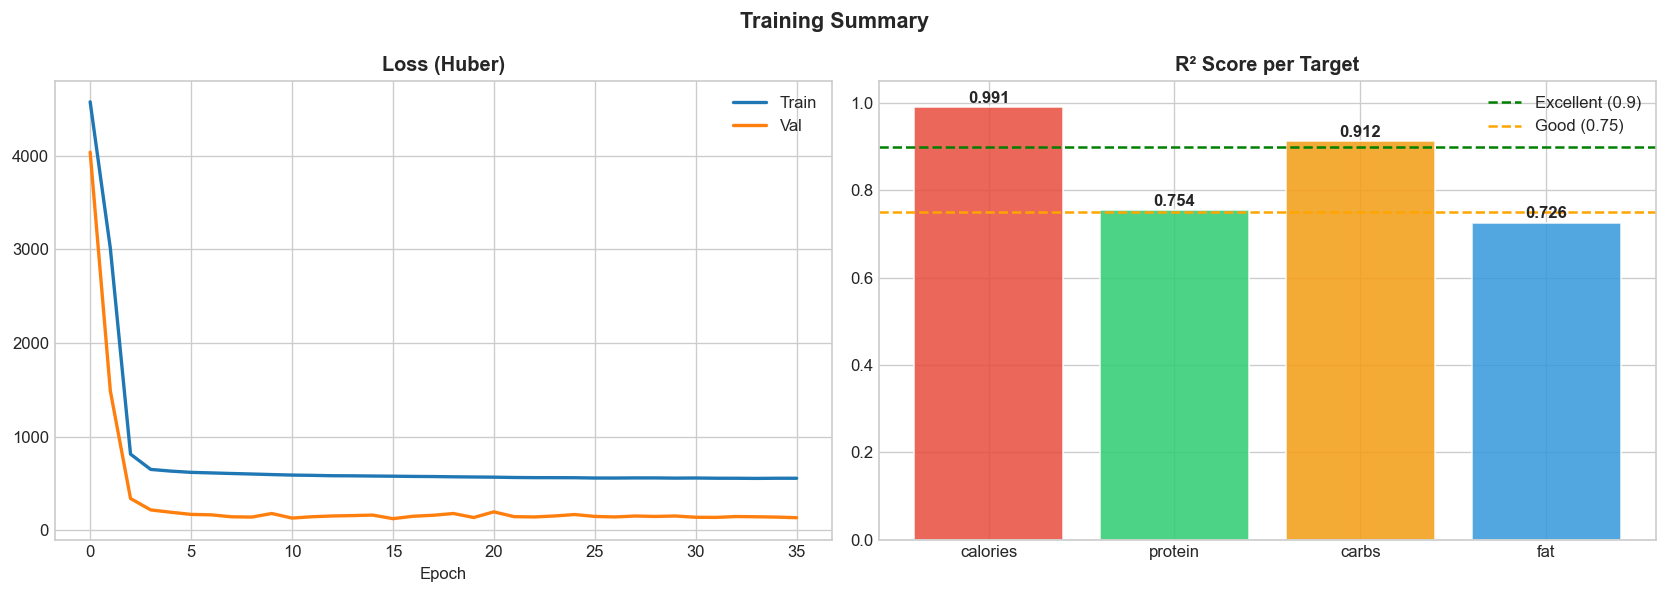

In [31]:
plt.rcParams['figure.dpi'] = 120
COLORS = ['#E74C3C','#2ECC71','#F39C12','#3498DB']

# ── 1) Training History ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     lw=2, label='Train')
axes[0].plot(history.history['val_loss'], lw=2, label='Val')
axes[0].set_title('Loss (Huber)', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].bar(TARGETS, r2_vals, color=COLORS, alpha=0.85, edgecolor='white')
axes[1].axhline(0.9, color='green', ls='--', lw=1.5, label='Excellent (0.9)')
axes[1].axhline(0.75, color='orange', ls='--', lw=1.5, label='Good (0.75)')
axes[1].set_title('R² Score per Target', fontweight='bold')
axes[1].set_ylim(0, 1.05)
axes[1].legend()
for i, v in enumerate(r2_vals):
    axes[1].text(i, v+0.01, f'{v:.3f}', ha='center', fontweight='bold')

plt.suptitle('Training Summary', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_1_training.png', dpi=150, bbox_inches='tight')
plt.show()

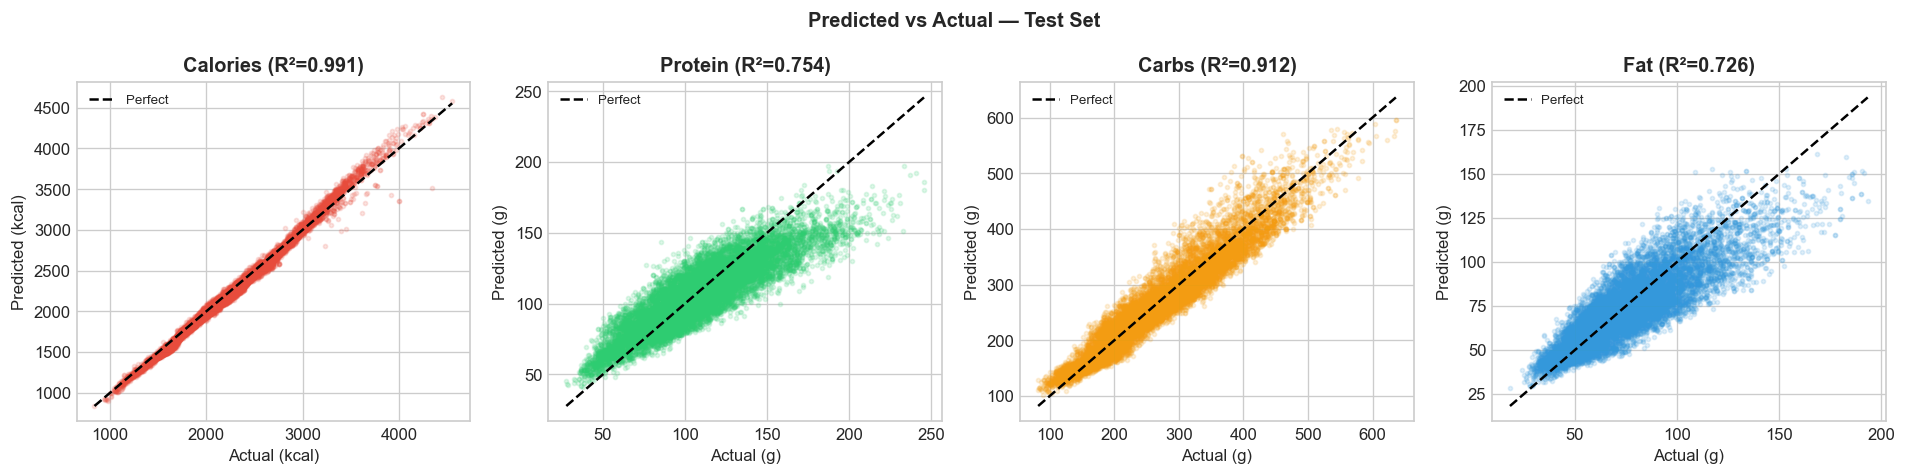

In [32]:
# ── 2) Actual vs Predicted ──
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
units = ['kcal','g','g','g']

for i, (t, color, unit) in enumerate(zip(TARGETS, COLORS, units)):
    actual    = y_test[t]
    predicted = preds[i].flatten()
    axes[i].scatter(actual, predicted, alpha=0.15, s=6, color=color)
    lo, hi = actual.min(), actual.max()
    axes[i].plot([lo,hi],[lo,hi],'k--', lw=1.5, label='Perfect')
    axes[i].set_title(f'{t.capitalize()} (R²={r2_vals[i]:.3f})', fontweight='bold')
    axes[i].set_xlabel(f'Actual ({unit})')
    axes[i].set_ylabel(f'Predicted ({unit})')
    axes[i].legend(fontsize=8)

plt.suptitle('Predicted vs Actual — Test Set', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_2_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

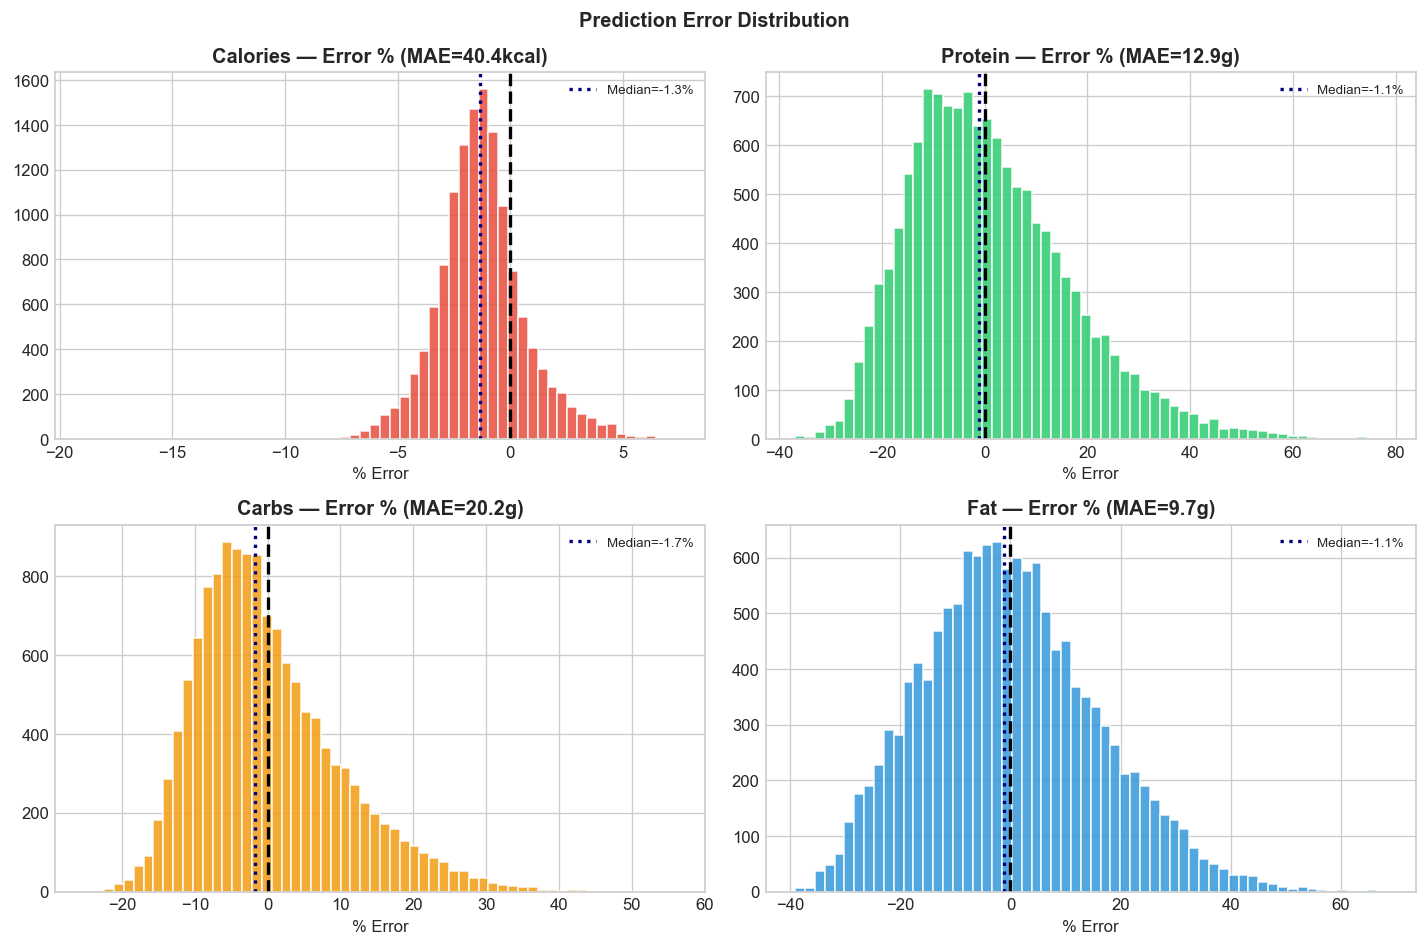

In [33]:
# ── 3) Error Distribution ──
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for i, (t, color, unit) in enumerate(zip(TARGETS, COLORS, units)):
    ax  = axes[i//2][i%2]
    err = (preds[i].flatten() - y_test[t]) / y_test[t] * 100
    ax.hist(err, bins=60, color=color, alpha=0.85, edgecolor='white')
    ax.axvline(0, color='black', ls='--', lw=2)
    ax.axvline(np.median(err), color='navy', ls=':', lw=2,
               label=f'Median={np.median(err):.1f}%')
    ax.set_title(f'{t.capitalize()} — Error % (MAE={mae_vals[i]:.1f}{unit})', fontweight='bold')
    ax.set_xlabel('% Error')
    ax.legend(fontsize=8)

plt.suptitle('Prediction Error Distribution', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_3_errors.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🔟 Inference


In [34]:
# ── Clinical Safety Rules (same as before) ──
RULES = {
    'healthy':            {'prot_kg':(0.8,2.2),  'carb_pct':(0.40,0.60), 'fat_pct':(0.20,0.35), 'prot_pct_max':0.35},
    'overweight':         {'prot_kg':(1.0,1.5),  'carb_pct':(0.35,0.50), 'fat_pct':(0.25,0.35), 'prot_pct_max':0.30},
    'insulin_resistance': {'prot_kg':(1.0,1.5),  'carb_pct':(0.30,0.45), 'fat_pct':(0.25,0.40), 'prot_pct_max':0.30},
    'underweight':        {'prot_kg':(1.2,2.0),  'carb_pct':(0.45,0.60), 'fat_pct':(0.25,0.35), 'prot_pct_max':0.30},
    'diabetes_type2':     {'prot_kg':(0.8,1.5),  'carb_pct':(0.30,0.45), 'fat_pct':(0.25,0.40), 'prot_pct_max':0.30},
    'hypertension':       {'prot_kg':(0.8,1.5),  'carb_pct':(0.40,0.55), 'fat_pct':(0.20,0.30), 'prot_pct_max':0.30},
    'obesity':            {'prot_kg':(1.0,1.5),  'carb_pct':(0.30,0.45), 'fat_pct':(0.25,0.35), 'prot_pct_max':0.30},
    'fatty_liver':        {'prot_kg':(1.0,1.5),  'carb_pct':(0.35,0.50), 'fat_pct':(0.20,0.30), 'prot_pct_max':0.30},
    'heart_disease':      {'prot_kg':(0.8,1.2),  'carb_pct':(0.45,0.60), 'fat_pct':(0.20,0.30), 'prot_pct_max':0.25},
    'hypothyroidism':     {'prot_kg':(1.0,1.5),  'carb_pct':(0.35,0.50), 'fat_pct':(0.25,0.35), 'prot_pct_max':0.30},
    'kidney_disease':     {'prot_kg':(0.6,0.8),  'carb_pct':(0.55,0.65), 'fat_pct':(0.25,0.35), 'prot_pct_max':0.20},
    'pcos':               {'prot_kg':(1.0,1.8),  'carb_pct':(0.30,0.45), 'fat_pct':(0.30,0.40), 'prot_pct_max':0.35},
}

In [35]:
def predict(inbody: dict, user: dict) -> dict:
    """
    Identical to API's run_prediction().
    inbody: raw InBody fields
    user:   goal, activity_level, disease_condition
    """
    data = {**inbody, **user}

    # Same preprocessor as API
    X = preprocessor.transform_single(data)

    # Predict
    raw = model.predict(X, verbose=0)
    cal  = max(800,  int(round(float(raw[0][0][0]))))
    prot = max(20,   round(float(raw[1][0][0]), 1))
    carb = max(20,   round(float(raw[2][0][0]), 1))
    fat  = max(10,   round(float(raw[3][0][0]), 1))

    # Macro %
    total = prot*4 + carb*4 + fat*9
    pct_p = round(prot*4 / total * 100, 1) if total else 0
    pct_c = round(carb*4 / total * 100, 1) if total else 0
    pct_f = round(fat*9  / total * 100, 1) if total else 0

    w   = data.get('weight', 70)
    dis = user.get('disease_condition', 'healthy')
    ru  = RULES.get(dis, RULES['healthy'])

    return {
        'calories': cal, 'protein': prot, 'carbs': carb, 'fat': fat,
        'pct_p': pct_p, 'pct_c': pct_c, 'pct_f': pct_f,
        'prot_kg': round(prot / w, 2),
        'macro_breakdown': {'protein_pct': pct_p, 'carbs_pct': pct_c, 'fat_pct': pct_f},
    }


def show(title: str, r: dict):
    print(f'\n{'='*55}')
    print(f'  {title}')
    print(f'{'='*55}')
    print(f'  Calories : {r["calories"]:>6} kcal')
    print(f'  Protein  : {r["protein"]:>6} g   ({r["pct_p"]}%)')
    print(f'  Carbs    : {r["carbs"]:>6} g   ({r["pct_c"]}%)')
    print(f'  Fat      : {r["fat"]:>6} g   ({r["pct_f"]}%)')
    print(f'  Prot/kg  : {r["prot_kg"]} g/kg body weight')

In [36]:
# ── Scenario 1: Healthy Male - Lose Fat ──
show('Scenario 1: Healthy Male - Lose Fat', predict(
    {'height':1.80,'weight':85,'age':28,'gender':'Male','muscle_mass':35,'body_fat_percentage':22},
    {'goal':'lose_fat','activity_level':3,'disease_condition':'healthy'}))


  Scenario 1: Healthy Male - Lose Fat
  Calories :   2207 kcal
  Protein  :  128.0 g   (23.4%)
  Carbs    :  247.6 g   (45.2%)
  Fat      :   76.6 g   (31.5%)
  Prot/kg  : 1.51 g/kg body weight


In [37]:
# ── Scenario 2: Diabetic Female - Lose Fat ──
show('Scenario 2: Diabetic Female - Lose Fat', predict(
    {'height':1.65,'weight':88,'age':52,'gender':'Female','muscle_mass':27,'body_fat_percentage':38},
    {'goal':'lose_fat','activity_level':2,'disease_condition':'diabetes_type2'}))


  Scenario 2: Diabetic Female - Lose Fat
  Calories :   1534 kcal
  Protein  :  109.0 g   (28.4%)
  Carbs    :  157.2 g   (41.0%)
  Fat      :   52.3 g   (30.7%)
  Prot/kg  : 1.24 g/kg body weight


In [38]:
# ── Scenario 3: Kidney Disease - Low Protein ──
show('Scenario 3: Kidney Disease - Maintain', predict(
    {'height':1.70,'weight':70,'age':60,'gender':'Male','muscle_mass':25,'body_fat_percentage':28},
    {'goal':'maintain','activity_level':2,'disease_condition':'kidney_disease'}))


  Scenario 3: Kidney Disease - Maintain
  Calories :   1992 kcal
  Protein  :   60.7 g   (12.3%)
  Carbs    :  293.3 g   (59.2%)
  Fat      :   62.7 g   (28.5%)
  Prot/kg  : 0.87 g/kg body weight


In [39]:
# ── Scenario 4: Underweight - Gain Muscle ──
show('Scenario 4: Underweight - Gain Muscle', predict(
    {'height':1.80,'weight':55,'age':22,'gender':'Male','muscle_mass':22,'body_fat_percentage':8},
    {'goal':'gain_muscle','activity_level':4,'disease_condition':'underweight'}))


  Scenario 4: Underweight - Gain Muscle
  Calories :   2983 kcal
  Protein  :   98.0 g   (13.5%)
  Carbs    :  412.2 g   (56.6%)
  Fat      :   96.8 g   (29.9%)
  Prot/kg  : 1.78 g/kg body weight


In [40]:
# ── Scenario 5: PCOS - Lose Fat ──
show('Scenario 5: PCOS Female - Lose Fat', predict(
    {'height':1.60,'weight':80,'age':30,'gender':'Female','muscle_mass':25,'body_fat_percentage':36},
    {'goal':'lose_fat','activity_level':3,'disease_condition':'pcos'}))


  Scenario 5: PCOS Female - Lose Fat
  Calories :   1760 kcal
  Protein  :  125.7 g   (28.6%)
  Carbs    :  173.8 g   (39.5%)
  Fat      :   62.4 g   (31.9%)
  Prot/kg  : 1.57 g/kg body weight


In [41]:
# ── Scenario 6: Obese Sedentary ──
show('Scenario 6: Obese Sedentary - Lose Fat', predict(
    {'height':1.78,'weight':115,'age':45,'gender':'Male','muscle_mass':35,'body_fat_percentage':38},
    {'goal':'lose_fat','activity_level':1,'disease_condition':'obesity'}))


  Scenario 6: Obese Sedentary - Lose Fat
  Calories :   1909 kcal
  Protein  :  141.5 g   (29.8%)
  Carbs    :  181.6 g   (38.3%)
  Fat      :   67.4 g   (31.9%)
  Prot/kg  : 1.23 g/kg body weight


In [42]:
# ── Scenario 7-12: الباقي ──
scenarios = [
    ('Heart Disease - Maintain',
     {'height':1.72,'weight':80,'age':62,'gender':'Male','muscle_mass':28,'body_fat_percentage':28},
     {'goal':'maintain','activity_level':2,'disease_condition':'heart_disease'}),
    ('Fatty Liver - Lose Fat',
     {'height':1.68,'weight':90,'age':40,'gender':'Male','muscle_mass':30,'body_fat_percentage':34},
     {'goal':'lose_fat','activity_level':2,'disease_condition':'fatty_liver'}),
    ('Insulin Resistance - Maintain',
     {'height':1.70,'weight':92,'age':38,'gender':'Female','muscle_mass':28,'body_fat_percentage':37},
     {'goal':'maintain','activity_level':3,'disease_condition':'insulin_resistance'}),
    ('Hypothyroidism - Lose Fat',
     {'height':1.62,'weight':78,'age':44,'gender':'Female','muscle_mass':24,'body_fat_percentage':36},
     {'goal':'lose_fat','activity_level':2,'disease_condition':'hypothyroidism'}),
    ('Healthy Female - Gain Muscle',
     {'height':1.65,'weight':58,'age':25,'gender':'Female','muscle_mass':22,'body_fat_percentage':24},
     {'goal':'gain_muscle','activity_level':4,'disease_condition':'healthy'}),
    ('Hypertension - Maintain',
     {'height':1.70,'weight':83,'age':55,'gender':'Male','muscle_mass':28,'body_fat_percentage':30},
     {'goal':'maintain','activity_level':2,'disease_condition':'hypertension'}),
]
for title, inbody, user in scenarios:
    show(f'Scenario: {title}', predict(inbody, user))


  Scenario: Heart Disease - Maintain
  Calories :   2140 kcal
  Protein  :   73.1 g   (13.8%)
  Carbs    :  300.8 g   (56.6%)
  Fat      :   70.1 g   (29.7%)
  Prot/kg  : 0.91 g/kg body weight

  Scenario: Fatty Liver - Lose Fat
  Calories :   1820 kcal
  Protein  :  105.6 g   (23.1%)
  Carbs    :  213.3 g   (46.7%)
  Fat      :   61.1 g   (30.1%)
  Prot/kg  : 1.17 g/kg body weight

  Scenario: Insulin Resistance - Maintain
  Calories :   2494 kcal
  Protein  :  122.3 g   (19.9%)
  Carbs    :  297.6 g   (48.4%)
  Fat      :   86.6 g   (31.7%)
  Prot/kg  : 1.33 g/kg body weight

  Scenario: Hypothyroidism - Lose Fat
  Calories :   1452 kcal
  Protein  :   97.5 g   (26.8%)
  Carbs    :  159.0 g   (43.7%)
  Fat      :   47.8 g   (29.5%)
  Prot/kg  : 1.25 g/kg body weight

  Scenario: Healthy Female - Gain Muscle
  Calories :   2538 kcal
  Protein  :  113.1 g   (18.1%)
  Carbs    :  315.8 g   (50.6%)
  Fat      :   86.6 g   (31.2%)
  Prot/kg  : 1.95 g/kg body weight

  Scenario: Hypertens

---
## 1️⃣1️⃣ Macro Heatmap — All Diseases

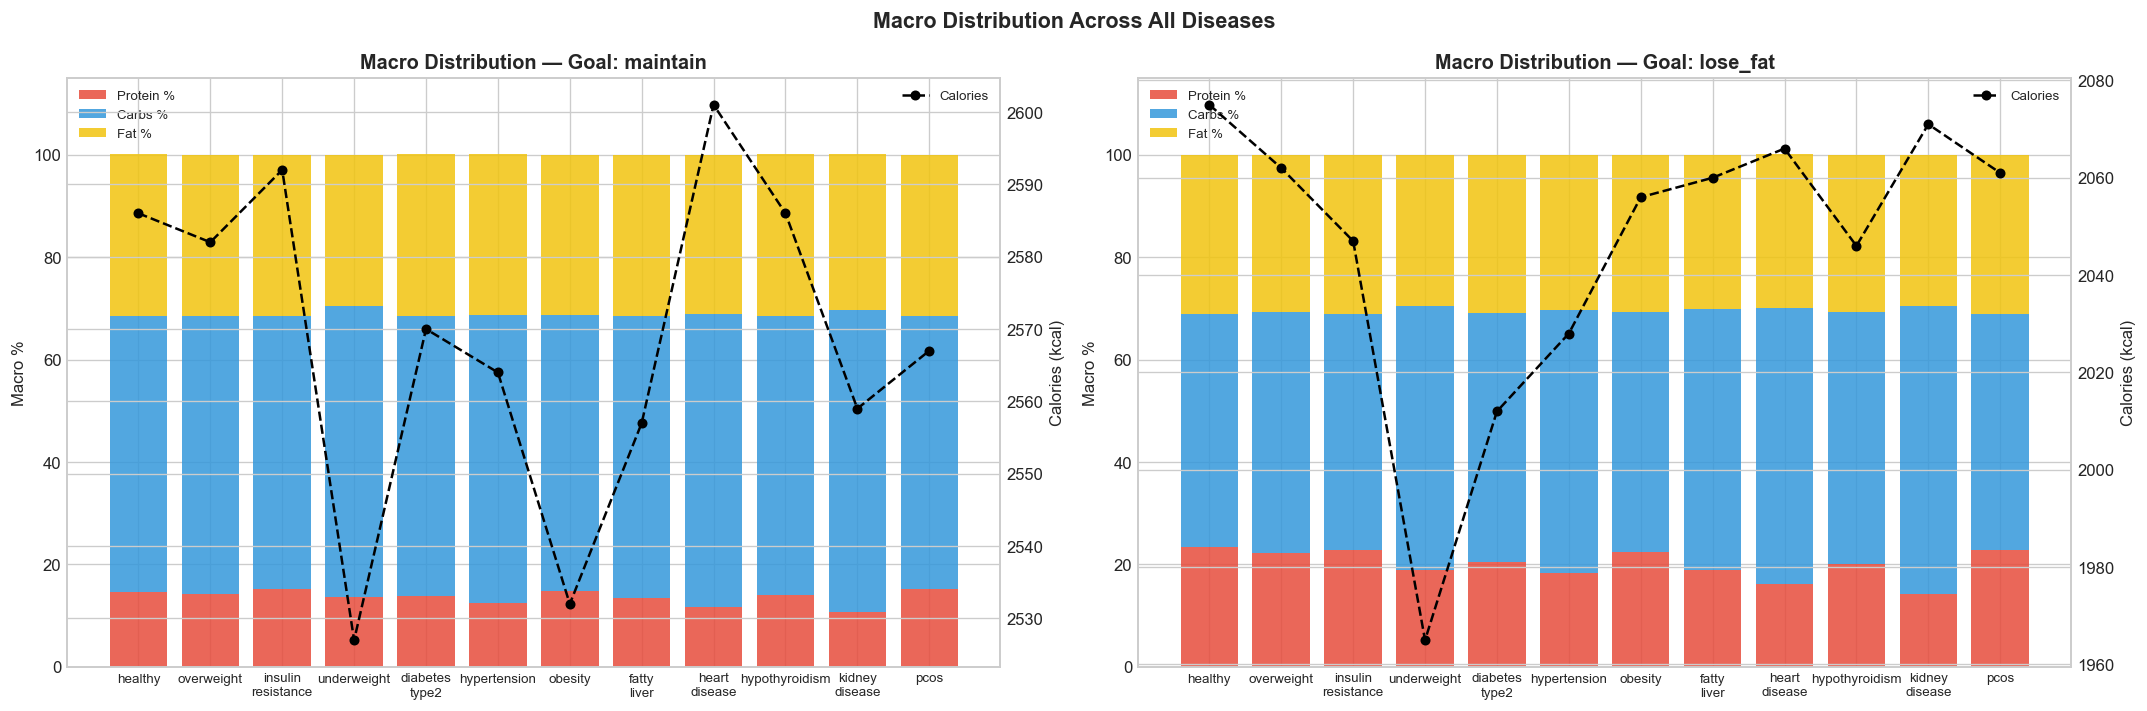

In [43]:
base = {'height':1.75,'weight':80,'age':35,'gender':'Male',
        'muscle_mass':30,'body_fat_percentage':25}

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax_idx, goal in enumerate(['maintain','lose_fat']):
    prot_p, carb_p, fat_p, cals = [], [], [], []
    for dis in DISEASES:
        r = predict(base, {'goal':goal,'activity_level':3,'disease_condition':dis})
        prot_p.append(r['pct_p'])
        carb_p.append(r['pct_c'])
        fat_p.append(r['pct_f'])
        cals.append(r['calories'])

    x = range(len(DISEASES))
    dis_labels = [d.replace('_','\n') for d in DISEASES]
    ax = axes[ax_idx]
    bars1 = ax.bar(x, prot_p, label='Protein %', color='#E74C3C', alpha=0.85)
    bars2 = ax.bar(x, carb_p, bottom=prot_p, label='Carbs %', color='#3498DB', alpha=0.85)
    fat_bottom = [p+c for p,c in zip(prot_p, carb_p)]
    bars3 = ax.bar(x, fat_p, bottom=fat_bottom, label='Fat %', color='#F1C40F', alpha=0.85)

    # Calorie line
    ax2 = ax.twinx()
    ax2.plot(x, cals, 'k--o', ms=5, lw=1.5, label='Calories')
    ax2.set_ylabel('Calories (kcal)')
    ax2.legend(loc='upper right', fontsize=8)

    ax.set_xticks(list(x))
    ax.set_xticklabels(dis_labels, fontsize=8)
    ax.set_ylim(0, 115)
    ax.set_ylabel('Macro %')
    ax.set_title(f'Macro Distribution — Goal: {goal}', fontweight='bold')
    ax.legend(loc='upper left', fontsize=8)

plt.suptitle('Macro Distribution Across All Diseases', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_4_macros.png', dpi=150, bbox_inches='tight')
plt.show()

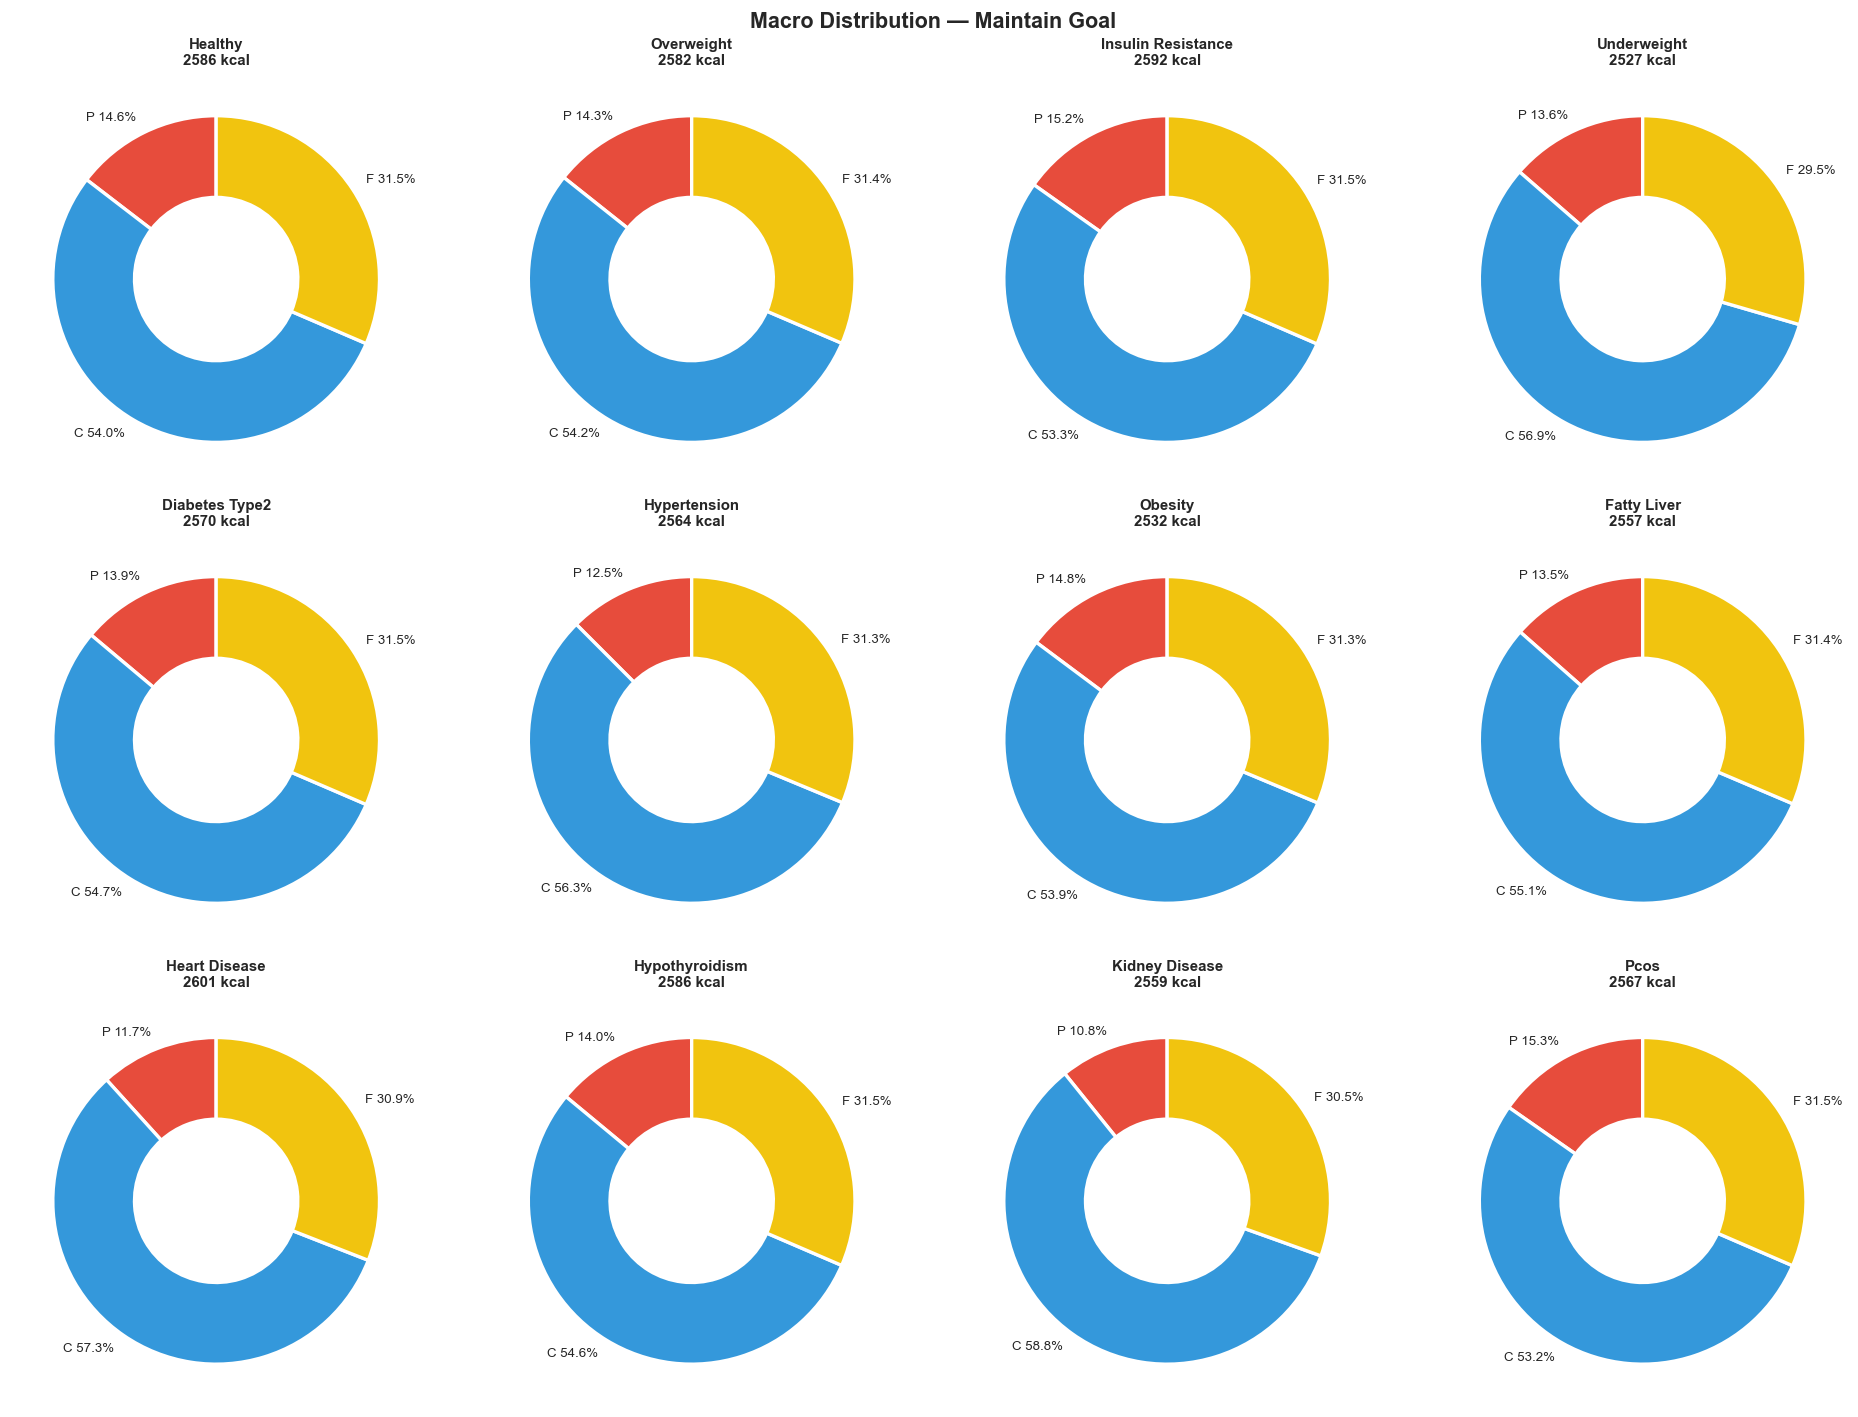

In [44]:
# ── Macro Pie Charts — All Diseases ──
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for idx, dis in enumerate(DISEASES):
    ax = axes[idx//4][idx%4]
    r  = predict(base, {'goal':'maintain','activity_level':3,'disease_condition':dis})
    sizes  = [r['pct_p'], r['pct_c'], r['pct_f']]
    colors = ['#E74C3C','#3498DB','#F1C40F']
    labels = [f'P {r["pct_p"]}%', f'C {r["pct_c"]}%', f'F {r["pct_f"]}%']
    ax.pie(sizes, colors=colors, labels=labels, startangle=90,
           wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2),
           textprops={'fontsize':8})
    ax.set_title(f"{dis.replace('_',' ').title()}\n{r['calories']} kcal",
                 fontsize=9, fontweight='bold')

plt.suptitle('Macro Distribution — Maintain Goal', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_5_pies.png', dpi=150, bbox_inches='tight')
plt.show()